# Tugas Klasifikasi Citra: Deteksi Jenis Sampah
## Transfer Learning (MobileNetV2) & Handling Overfitting

Dataset: **Trash Type Image Dataset** (Kaggle - Farzad Nekouei)
Link: https://www.kaggle.com/datasets/farzadnekouei/trash-type-image-dataset

Dataset ini berisi gambar sampah yang terbagi ke dalam 6 kategori:
`cardboard`, `glass`, `metal`, `paper`, `plastic`, `trash`.

Notebook ini mengikuti alur yang sama seperti tugas sebelumnya:
1. **Transfer Learning** menggunakan arsitektur `MobileNetV2`.
2. **Pengecekan Overfitting** menggunakan plot grafik Loss dan Accuracy.
3. **Handling Overfitting** menggunakan gabungan teknik *Data Augmentation*, *Dropout*, dan *Early Stopping*.
4. **Evaluasi Model** menggunakan Confusion Matrix & Classification Report.

> **Catatan:** Notebook ini dirancang untuk dijalankan di Google Colab atau Jupyter lokal yang memiliki koneksi internet (untuk mengunduh dataset dari Kaggle dan bobot ImageNet).

### 1. Import Library

In [1]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Menghindari peringatan (warnings) agar tampilan rapi
tf.get_logger().setLevel('ERROR')


### 2. Unduh Dataset dari Kaggle
Menggunakan `kagglehub` untuk mengunduh dataset "Trash Type Image Dataset" secara otomatis.

Jika muncul permintaan autentikasi Kaggle (khususnya saat dijalankan di luar Colab), siapkan file `kaggle.json` (dari akun Kaggle Anda -> Settings -> Create New API Token) dan simpan di `~/.kaggle/kaggle.json`.

In [2]:
import kagglehub

# Mengunduh dataset. Fungsi ini akan menampilkan path lokal tempat dataset disimpan
download_path = kagglehub.dataset_download("farzadnekouei/trash-type-image-dataset")
print("Dataset terunduh di:", download_path)

# Mencari folder utama yang langsung berisi sub-folder kategori (cardboard, glass, dll.)
dataset_dir = None
for root, dirs, files in os.walk(download_path):
    if len(dirs) >= 2 and all(
        os.path.isdir(os.path.join(root, d)) for d in dirs
    ):
        # pastikan sub-folder tersebut berisi gambar, bukan folder kosong
        sample_dir = os.path.join(root, dirs[0])
        if any(f.lower().endswith(('.jpg', '.jpeg', '.png')) for f in os.listdir(sample_dir)):
            dataset_dir = root
            break

print("dataset_dir ditemukan:", dataset_dir)
print("Kategori:", sorted(os.listdir(dataset_dir)))


c:\Users\user\Documents\ML\Week 10\venv_sampah\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 40.9M/40.9M [00:11<00:00, 3.68MB/s]

Extracting files...


Dataset terunduh di: C:\Users\user\.cache\kagglehub\datasets\farzadnekouei\trash-type-image-dataset\versions\1
dataset_dir ditemukan: C:\Users\user\.cache\kagglehub\datasets\farzadnekouei\trash-type-image-dataset\versions\1\TrashType_Image_Dataset
Kategori: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


### 3. Eksplorasi Data & Visualisasi Gambar Sampah
Melihat distribusi jumlah gambar pada setiap kategori dan contoh gambar dari dataset.

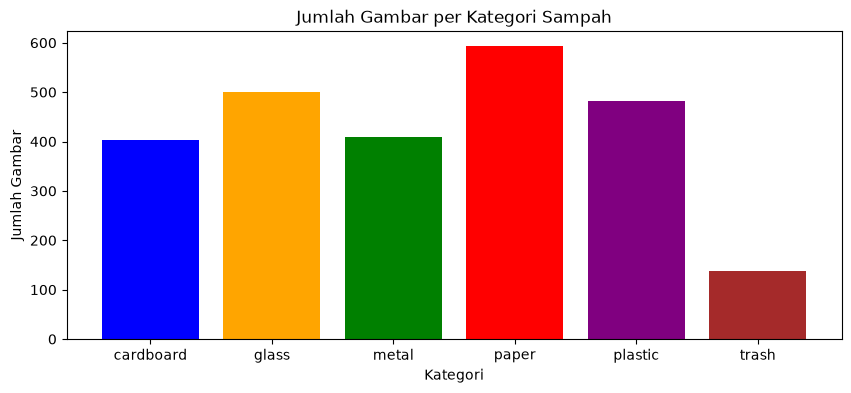

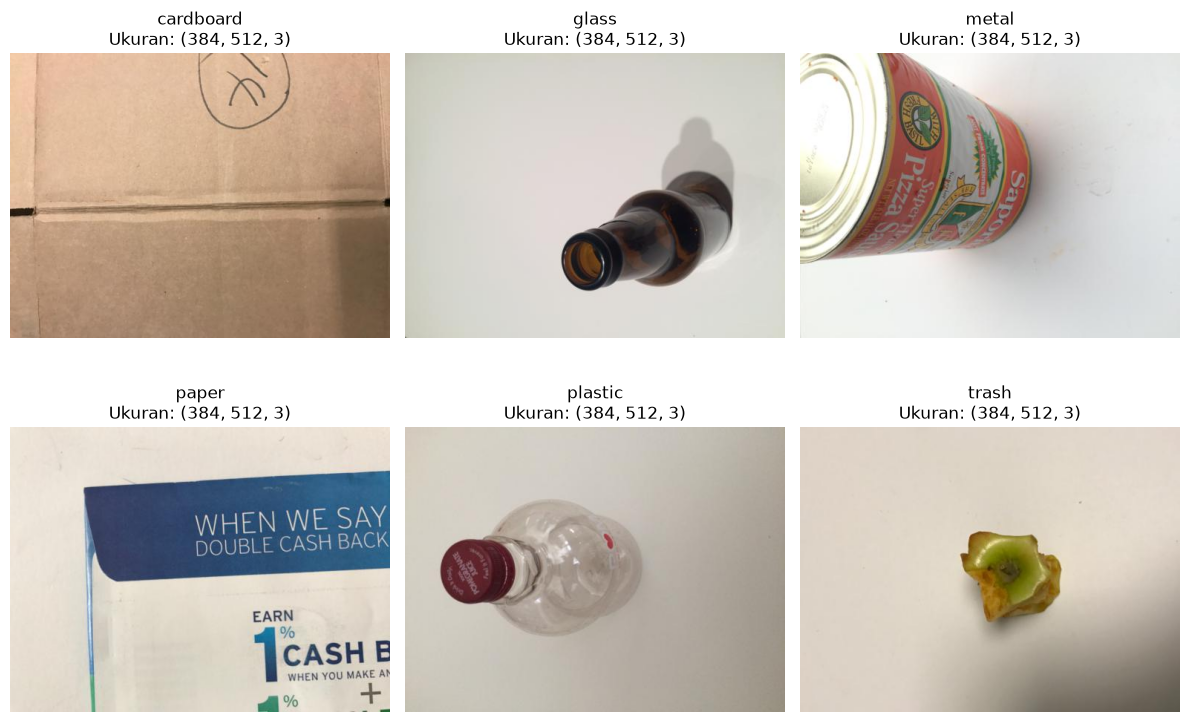

In [3]:
kategori = sorted(os.listdir(dataset_dir))

# 1. Bar Chart Distribusi Data
jumlah_data = [len(os.listdir(os.path.join(dataset_dir, kat))) for kat in kategori]

plt.figure(figsize=(10, 4))
plt.bar(kategori, jumlah_data, color=['blue', 'orange', 'green', 'red', 'purple', 'brown'])
plt.title('Jumlah Gambar per Kategori Sampah')
plt.ylabel('Jumlah Gambar')
plt.xlabel('Kategori')
plt.show()

# 2. Menampilkan Contoh Gambar dari setiap kategori
plt.figure(figsize=(12, 8))
for i, kat in enumerate(kategori):
    folder_path = os.path.join(dataset_dir, kat)
    contoh_gambar = os.listdir(folder_path)[0]  # Ambil gambar pertama
    img_path = os.path.join(folder_path, contoh_gambar)

    img = mpimg.imread(img_path)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"{kat}\nUkuran: {img.shape}")
    plt.axis('off')

plt.tight_layout()
plt.show()


### 4. Data Preprocessing & Augmentation (Teknik Mencegah Overfitting)
Menggunakan `ImageDataGenerator` dengan augmentasi (rotasi, pergeseran, zoom, flip) agar model belajar fitur sampah dari berbagai sudut pandang, sehingga lebih tahan terhadap overfitting.

In [4]:
img_size = (224, 224)
batch_size = 32

# Augmentasi Data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # 20% data digunakan sebagai data validasi
)

print("Memuat Data Training:")
train_data = train_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

print("\nMemuat Data Validasi:")
val_data = train_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

class_names = list(train_data.class_indices.keys())
print(f"\nKategori Sampah: {class_names}")


Memuat Data Training:
Found 2024 images belonging to 6 classes.

Memuat Data Validasi:
Found 503 images belonging to 6 classes.

Kategori Sampah: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


### 5. Membangun Model Transfer Learning (MobileNetV2) & Dropout
Menggunakan `MobileNetV2` yang telah dilatih pada jutaan gambar (ImageNet). Layer dasarnya "dibekukan" (*freeze*) agar bobot pengetahuannya tidak hilang.

Ditambahkan layer **Dropout(0.5)** sebelum output sebagai teknik kedua untuk **mengurangi overfitting**.

In [5]:
# 1. Load Base Model (MobileNetV2)
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze (Bekukan) base model

# 2. Tambahkan Custom Layer di atasnya
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)

# 3. Handling Overfitting: Dropout
x = Dropout(0.5)(x)

# Output layer (6 kategori sampah)
predictions = Dense(train_data.num_classes, activation='softmax')(x)

# 4. Gabungkan & Compile Model
model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 6. Pelatihan Model dengan Early Stopping
Teknik penanganan overfitting ketiga adalah **Early Stopping**. `val_loss` dipantau; jika tidak membaik selama 5 epoch berturut-turut, pelatihan otomatis dihentikan dan bobot terbaik dikembalikan.

In [6]:
# Handling Overfitting: Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

epochs = 20

# Proses Pelatihan (Training)
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=epochs,
    callbacks=[early_stop]
)


Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 31s 444ms/step - accuracy: 0.5346 - loss: 1.1980 - val_accuracy: 0.7117 - val_loss: 0.7719
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 27s 418ms/step - accuracy: 0.7026 - loss: 0.7867 - val_accuracy: 0.7594 - val_loss: 0.6762
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 410ms/step - accuracy: 0.7515 - loss: 0.6738 - val_accuracy: 0.7654 - val_loss: 0.6799
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 28s 430ms/step - accuracy: 0.7658 - loss: 0.6156 - val_accuracy: 0.7813 - val_loss: 0.6612
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 27s 419ms/step - accuracy: 0.7969 - loss: 0.5828 - val_accuracy: 0.7833 - val_loss: 0.6025
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 402ms/step - accuracy: 0.8073 - loss: 0.5207 - val_accuracy: 0.7853 - val_loss: 0.6551
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 404ms/step - accuracy: 0.8113 - loss: 0.5128 - val_accuracy: 0.7992 - val_loss: 0.6251
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 406ms/step - accuracy: 0.8350 - loss: 0.4558 - val_accu

### 7. Pengecekan Overfitting (Evaluasi Grafik)
Jika garis *Training* dan *Validation* berjalan berdekatan, serta *Validation Loss* tidak melonjak naik, maka overfitting telah berhasil ditangani.

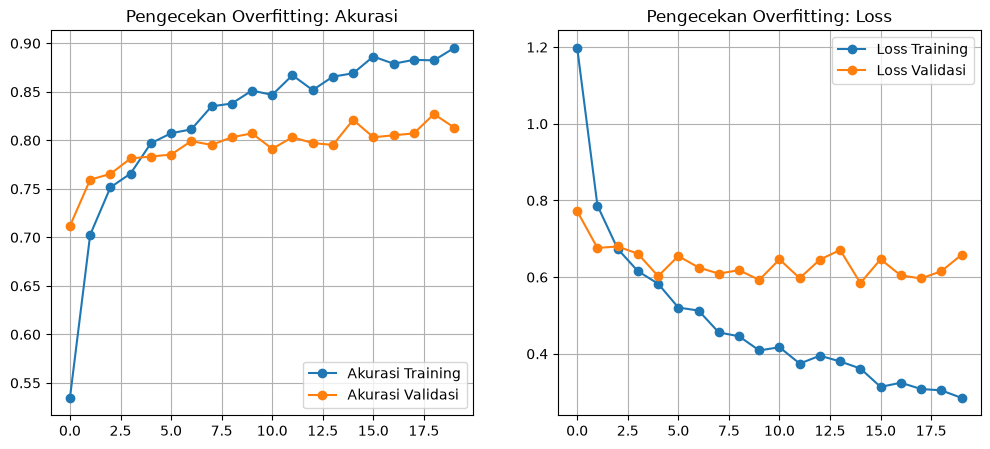

In [7]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Grafik Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Akurasi Training', marker='o')
plt.plot(epochs_range, val_acc, label='Akurasi Validasi', marker='o')
plt.legend(loc='lower right')
plt.title('Pengecekan Overfitting: Akurasi')
plt.grid(True)

# Grafik Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Loss Training', marker='o')
plt.plot(epochs_range, val_loss, label='Loss Validasi', marker='o')
plt.legend(loc='upper right')
plt.title('Pengecekan Overfitting: Loss')
plt.grid(True)

plt.show()


### 8. Evaluasi Model: Confusion Matrix & Classification Report
Melihat performa model per kategori pada data validasi, untuk mengetahui kategori mana yang paling sering tertukar.

16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 405ms/step
Classification Report:

              precision    recall  f1-score   support

   cardboard       0.90      0.95      0.93        80
       glass       0.76      0.81      0.78       100
       metal       0.84      0.77      0.80        82
       paper       0.86      0.86      0.86       118
     plastic       0.79      0.66      0.72        96
       trash       0.50      0.74      0.60        27

    accuracy                           0.80       503
   macro avg       0.78      0.80      0.78       503
weighted avg       0.81      0.80      0.80       503



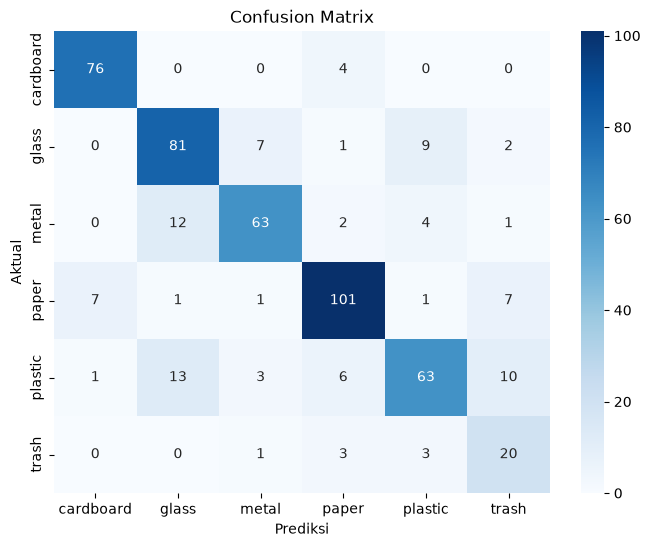

In [8]:
# Prediksi pada data validasi
val_data.reset()
y_pred_prob = model.predict(val_data)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = val_data.classes

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()


### 9. Uji Coba Prediksi pada Beberapa Gambar Validasi
Menampilkan beberapa gambar beserta label aktual dan prediksi model secara visual.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 762ms/step


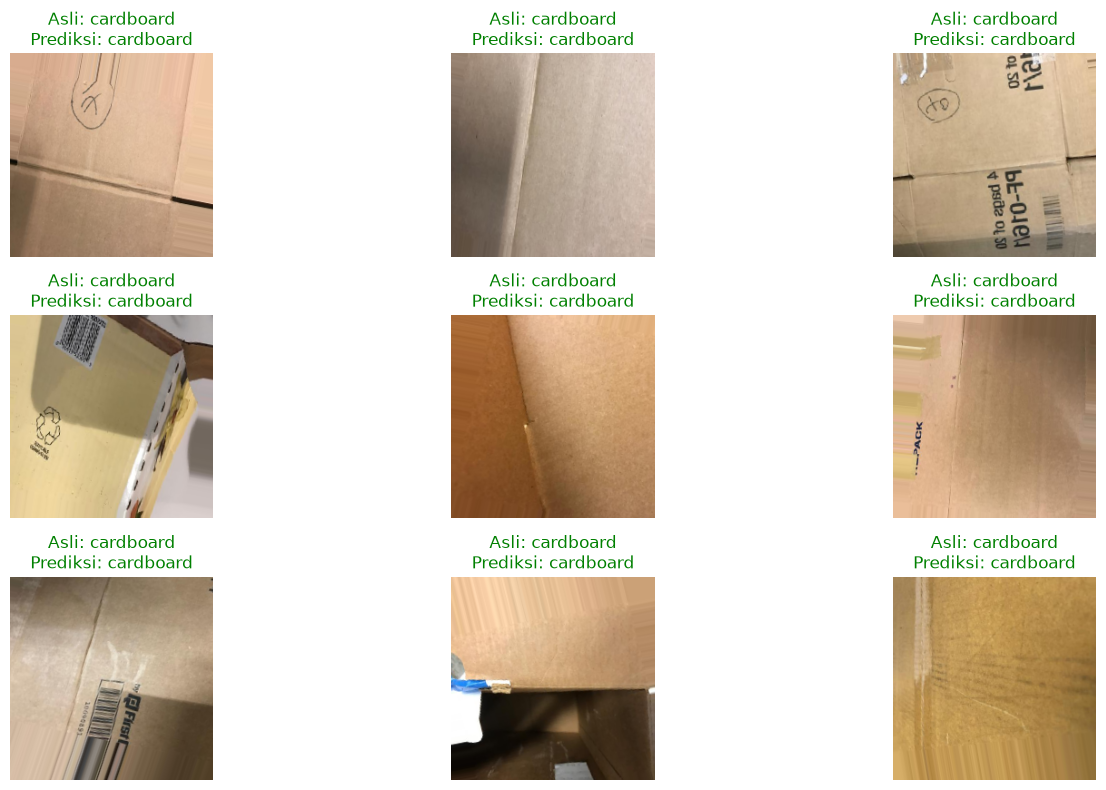

In [9]:
val_data.reset()
images, labels = next(val_data)

preds = model.predict(images)
pred_labels = np.argmax(preds, axis=1)
true_labels = np.argmax(labels, axis=1)

plt.figure(figsize=(15, 8))
for i in range(min(9, len(images))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    warna = 'green' if pred_labels[i] == true_labels[i] else 'red'
    plt.title(f"Asli: {class_names[true_labels[i]]}\nPrediksi: {class_names[pred_labels[i]]}", color=warna)
    plt.axis('off')

plt.tight_layout()
plt.show()


### 10. Menyimpan Model
Menyimpan model yang telah dilatih agar bisa digunakan kembali tanpa perlu melatih ulang.

In [10]:
model.save('model_klasifikasi_sampah.keras')
print("Model berhasil disimpan sebagai 'model_klasifikasi_sampah.keras'")


Model berhasil disimpan sebagai 'model_klasifikasi_sampah.keras'
